You are a computer vision
engineer at FreshTrack, a produce supply chain company. Warehouses receive
mixed crates of fruit and need to automatically sort them by type, flag color
defects (underripe or overripe), and count individual pieces before packing. Manual
inspection is slow and inconsistent under variable warehouse lighting. Your job
is to build a CV pipeline using OpenCV that can: (1) identify fruit types by
color, (2) clean up noisy camera images, (3) detect fruit shape features, and
(4) count individual round fruits in a batch image.




Images to Use


red_apple.jpg, green_apple.jpg, banana.jpg,
strawberry.jpg, orange.jpg, lime.jpg — individual fruit images (Fruits-360
dataset subset)
mixed_bowl.jpg — a single image containing multiple
fruits; used for the full pipeline and counting tasks
morphology.png — binary morphology demo image
chessboard.png — high-contrast grid for Harris corner
calibration
All images provided below
Part A — Color Space & Fruit Segmentation







1. Load red_apple.jpg in BGR using cv2.imread(). Display
it correctly in Matplotlib (convert to RGB first). Then display the raw BGR
version. What do you notice about the colors?
2. Convert red_apple.jpg to HSV. Visualize the H, S, and V
channels side by side as grayscale images. Which channel best separates the
fruit from its white background?


3. Masking by color: use cv2.inRange() in HSV to isolate
the red apple. Red wraps around the Hue axis (0–10 and 170–180). Create two
masks and combine with cv2.bitwise_or(). Display: original | mask | masked
result.


4.  Color table task: repeat the HSV masking for
green_apple.jpg, banana.jpg, and lime.jpg. Record each fruit’s working HSV
range as a markdown table: Fruit | H_min | H_max | S_min | S_max | V_min |
V_max.


5. Apply manual brightness/contrast to a dark banana image
(alpha=1.3, beta=20) using NumPy. Clip to [0,255] and convert to uint8. Compare
to cv2.convertScaleAbs(). Does it make the HSV mask more reliable?


6.  Reflection: why does HSV work better than RGB for fruit
color segmentation? When would it fail? (Hint: try a very dark purple grape or
blueberry.)

Part B — Histograms & Filtering



1. Load strawberry.jpg as grayscale. Plot its histogram.
Is the image well-exposed? What does the histogram shape tell you about
contrast?
2. Apply global histogram equalization
(cv2.equalizeHist()). Then apply CLAHE with clipLimit=2.0 and clipLimit=8.0.
Show all four versions side by side (original, equalized, CLAHE-2, CLAHE-8).
Which helps the HSV segmentation mask most?
3. Noise experiment: add Gaussian noise (mean=0, std=25)
to orange.jpg using np.random.normal(). Apply Gaussian blur, median filter, and
bilateral filter. Which removes the noise best while keeping the fruit’s edge
sharp? Plot all four for comparison.
4.  Extended — manual convolution: implement conv2d() from
scratch. Apply a Sobel X kernel to the grayscale banana image. Compare to
cv2.filter2D(). What is the mean absolute difference? Explain any discrepancy.













Part C — Morphology & Mask Cleanup



A raw HSV color mask is rarely
clean — it has small noise blobs from reflections and gaps from shadows.
Morphological operations fix this before any shape analysis.

5. Take your banana HSV mask from Part A. Apply erosion
with a 5×5 kernel. What happens to the mask?

6. Apply opening (erosion then dilation) to remove noise.
Apply closing (dilation then erosion) to fill holes. Show all four: raw mask after erosion | after opening | after closing.

7.  Apply the morphological gradient (dilation − erosion)
to extract just the outline of the banana. Overlay it on the original image in green.

8. Reflection: what would happen if you applied morphological operations directly to the BGR fruit image instead of the binary mask? Try it and describe what you see.

9. Demo with j.png: apply erosion, dilation, opening,
closing, Top Hat, and Black Hat. Show all six results. Which operation isolates
the thin strokes?

















Part D — Shape & Feature Detection



10. Canny
edge detection: run cv2.Canny() on grayscale green_apple.jpg with threshold
pairs [30, 100] and [100, 200]. Show both results. Which captures the fruit
outline cleanly without noise inside? Explain what happens at each stage of the
Canny pipeline.
11. Extended
— Canny from scratch: use the provided CannyEdgeDetector class to run the full
pipeline step by step on the same image (Gaussian blur → gradient
magnitude/direction → NMS → double threshold → hysteresis). Compare to
cv2.Canny().
12. Harris
corners on chessboard.jpg: run cv2.cornerHarris() and dilate the response map.
Threshold and mark corners as red dots. Adjust the response threshold from 0.01
to 0.1 — what changes?
13. Hough
Circle Transform on mixed_bowl.jpg: run cv2.HoughCircles() with minRadius=30,
maxRadius=100. Tune param2 (accumulator threshold) until you detect the round
fruits cleanly. Draw circles and center points. How many round fruits does your
detector count? Does it match the actual number?











14. Full
pipeline: for one fruit of your choice from mixed_bowl.jpg, run the complete
pipeline: load → BGR-to-RGB display → HSV mask → morphological cleanup → Canny
edges → draw bounding box → save with safe_imwrite(). This is your final
deliverable for Part D.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("moltean/fruits")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruits' dataset.
Path to dataset files: /kaggle/input/fruits


In [6]:
import os
print(os.listdir(path))

['fruits-360_100x100', 'fruits-360_3-body-problem', 'fruits-360_meta', 'fruits-360_original-size', 'fruits-360_multi']


In [21]:
import os
import cv2
import matplotlib.pyplot as plt


train_dir = os.path.join(path, 'fruits-360_100x100','fruits-360', 'Training')
if not os.path.exists(train_dir):
    train_dir = os.path.join(path, 'fruits-360_100x100', 'Training')

print(f"Searching in: {train_dir}")
available_folders = os.listdir(train_dir) if os.path.exists(train_dir) else []

def get_fruit_path(search_term):
    for folder in available_folders:
        if search_term.lower() in folder.lower():
            folder_path = os.path.join(train_dir, folder)
            files = os.listdir(folder_path)
            if files:
                # Prioritize '0_100.jpg' if it exists in the folder
                if '0_100.jpg' in files:
                    return os.path.join(folder_path, '0_100.jpg')
                return os.path.join(folder_path, files[0])
    return None

image_paths = {
    'red_apple': get_fruit_path('Apple Red 1'),
    'green_apple': get_fruit_path('Apple Golden 1'),
    'banana': get_fruit_path('Banana'),
    'strawberry': get_fruit_path('Strawberry'),
    'orange': get_fruit_path('Orange'),
    'lime': get_fruit_path('Lime'),
    'mixed_bowl': '/content/mixed_fruit_bowl.jpeg',
    'morphology': '/content/morphology.png',
    'chessboard': '/content/chessboard.png'
}

for name, p in image_paths.items():
    print(f"{name}: {p}")

Searching in: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
red_apple: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Apple Red 1/0_100.jpg
green_apple: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Apple Golden 1/0_100.jpg
banana: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Banana 4/r1_160_100.jpg
strawberry: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Strawberry 1/0_100.jpg
orange: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Tomato Cherry Orange 1/r1_160_100.jpg
lime: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Limes 1/0_100.jpg
mixed_bowl: /content/mixed_fruit_bowl.jpeg
morphology: /content/morphology.png
chessboard: /content/chessboard.png


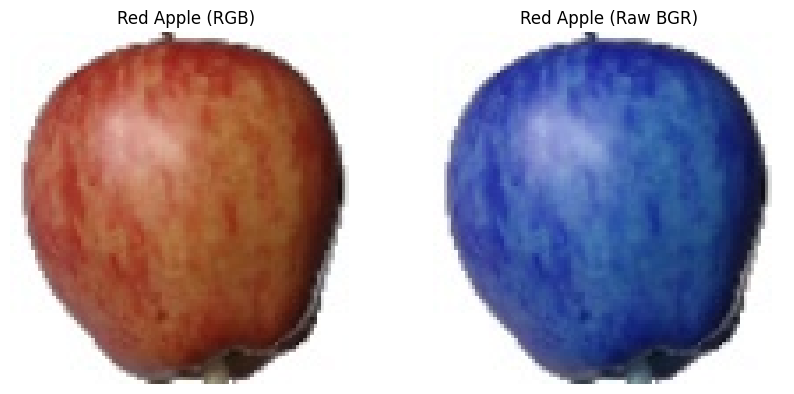

Observation: In BGR, the red apple appears blue because the Red and Blue channels are swapped.


In [22]:
import numpy as np

# Refine path mapping for green apple and orange fruit
image_paths['green_apple'] = get_fruit_path('Apple Golden 1')
image_paths['orange'] = get_fruit_path('Orange')

# --- Part A, Step 1: BGR vs RGB ---
img_path = image_paths['red_apple']
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Red Apple (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_bgr)
plt.title('Red Apple (Raw BGR)')
plt.axis('off')
plt.show()

print("Observation: In BGR, the red apple appears blue because the Red and Blue channels are swapped.")

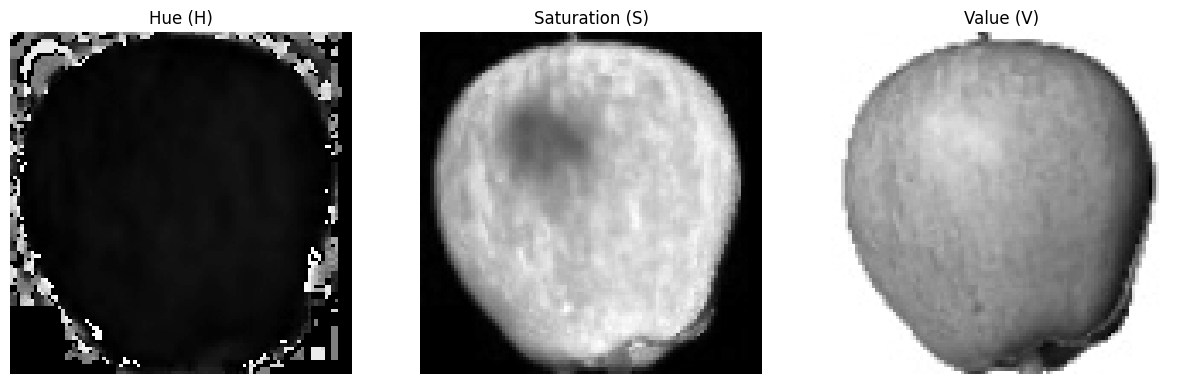

Analysis: The Saturation (S) or Value (V) channels usually provide the best contrast against white backgrounds.


In [23]:
# --- Part A, Step 2: HSV Visualization ---
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(h, cmap='gray')
plt.title('Hue (H)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(s, cmap='gray')
plt.title('Saturation (S)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(v, cmap='gray')
plt.title('Value (V)')
plt.axis('off')
plt.show()

print("Analysis: The Saturation (S) or Value (V) channels usually provide the best contrast against white backgrounds.")

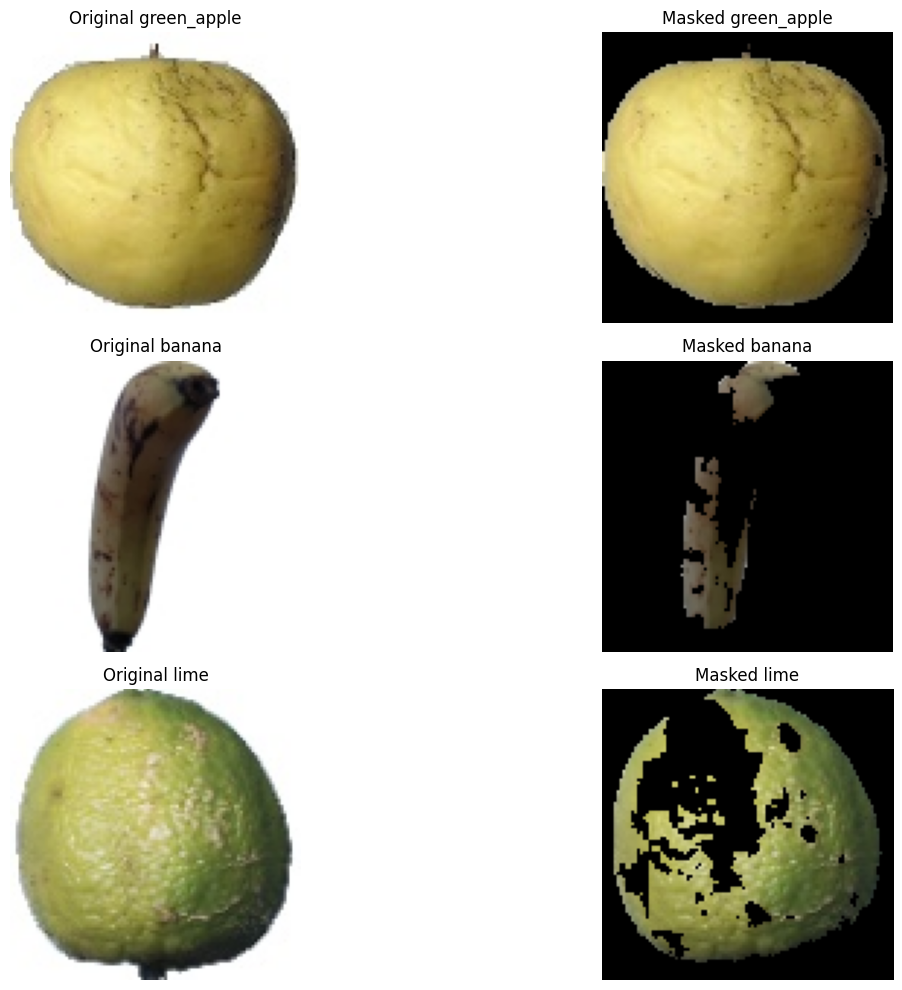

Mean Difference between NumPy and OpenCV methods: 0.1096


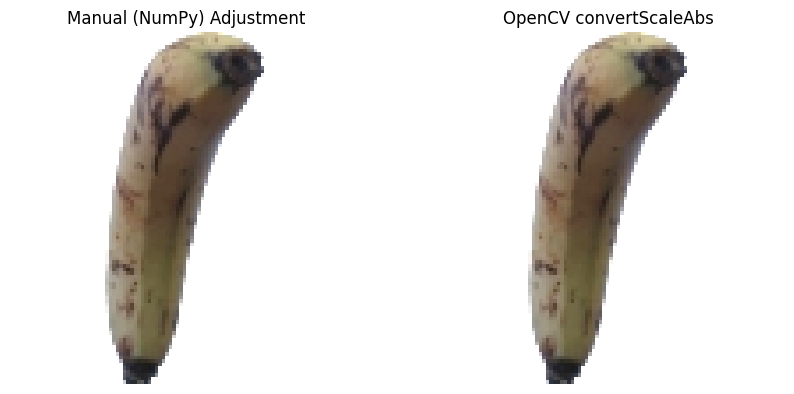

Mean pixel difference: 0.1096
Foreground px before: 1014
Foreground px after:  1278


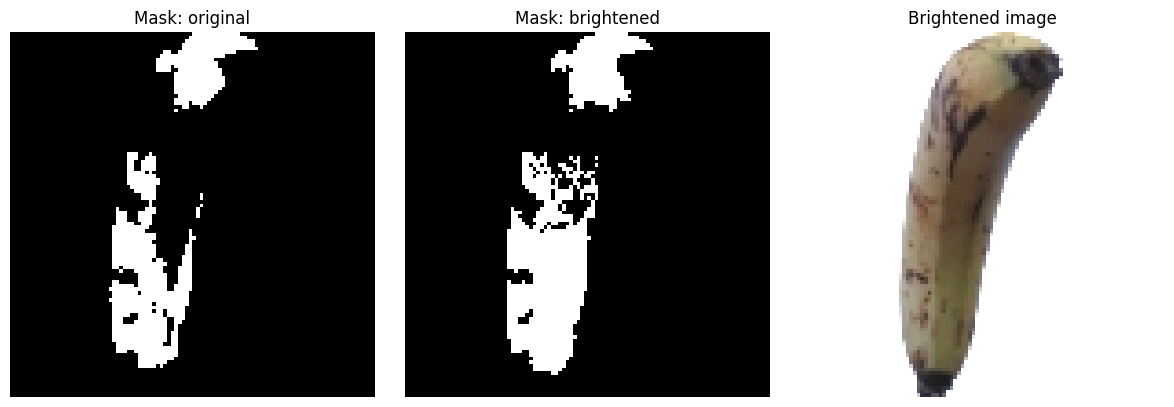

In [41]:
def get_mask(img_bgr, lower, upper):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower, upper)
    res = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    return mask, cv2.cvtColor(res, cv2.COLOR_BGR2RGB)

# Define HSV ranges based on standard values for these fruits
# Format: [H_min, S_min, V_min], [H_max, S_max, V_max]
ranges = {
    'green_apple': ([15, 40, 40], [45, 255, 255]),   # yellow-green hue, wide S/V
    'banana':      ([15, 10, 60], [50, 255, 255]),   # lower S floor to catch dull/bruised spots
    'lime':        ([30, 40, 40], [85, 255, 255])
}


# 4. Color Table Task and Visualization
plt.figure(figsize=(15, 10))
for i, fruit in enumerate(['green_apple', 'banana', 'lime']):
    img = cv2.imread(image_paths[fruit])
    low, high = ranges[fruit]
    mask, result = get_mask(img, np.array(low), np.array(high))

    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Original {fruit}')
    plt.axis('off')

    plt.subplot(3, 2, 2*i + 2)
    plt.imshow(result)
    plt.title(f'Masked {fruit}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# 5. Brightness/Contrast Task
banana_img = cv2.imread(image_paths['banana'])
alpha = 1.3
beta = 20

# NumPy Manual Adjustment
manual_adj = np.clip(alpha * banana_img.astype(np.float32) + beta, 0, 255).astype(np.uint8)

# OpenCV adjustment
cv2_adj = cv2.convertScaleAbs(banana_img, alpha=alpha, beta=beta)

# Comparison
diff = np.mean(np.abs(manual_adj.astype(float) - cv2_adj.astype(float)))
print(f"Mean Difference between NumPy and OpenCV methods: {diff}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(manual_adj, cv2.COLOR_BGR2RGB)); plt.title('Manual (NumPy) Adjustment'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(cv2_adj, cv2.COLOR_BGR2RGB)); plt.title('OpenCV convertScaleAbs'); plt.axis('off')
plt.show()


banana_img = cv2.imread(image_paths['banana'])
alpha, beta = 1.3, 20

# Manual (NumPy)
manual_adj = np.clip(alpha * banana_img.astype(np.float32) + beta, 0, 255).astype(np.uint8)

# OpenCV
cv2_adj = cv2.convertScaleAbs(banana_img, alpha=alpha, beta=beta)

diff = np.mean(np.abs(manual_adj.astype(float) - cv2_adj.astype(float)))
print(f"Mean pixel difference: {diff:.4f}")  # should be ~0, both do the same clipped linear transform

# Masks before/after adjustment
low, high = np.array(ranges['banana'][0]), np.array(ranges['banana'][1])
mask_before, _ = get_mask(banana_img, low, high)
mask_after, _  = get_mask(cv2_adj, low, high)

print("Foreground px before:", np.sum(mask_before > 0))
print("Foreground px after: ", np.sum(mask_after > 0))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mask_before, cmap='gray'); plt.title('Mask: original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask_after, cmap='gray'); plt.title('Mask: brightened'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(cv2_adj, cv2.COLOR_BGR2RGB)); plt.title('Brightened image'); plt.axis('off')
plt.tight_layout(); plt.show()

### Reflection: HSV vs RGB for Color Segmentation

**Why HSV is Superior:**
*   **Decouples Lighting:** RGB mixes color and brightness in every channel. HSV separates **Hue** (color identity) from **Saturation** (purity) and **Value** (brightness).
*   **Robustness:** Thresholding Hue is more stable against shadows, glare, and varying exposure compared to 3D RGB boundaries. This allows for narrower, more reliable color definitions.

**Failure Modes:**
*   **Hue Wrapping:** Red exists at both ends of the scale (0 and 179), requiring two separate masks.
*   **Achromatic Noise:** In very dark (low V) or near-white (low S) areas, Hue becomes mathematically unstable and noisy.
*   **Hue Overlap:** Different fruits (e.g., lime vs. green apple) may share identical Hue ranges, requiring shape or texture analysis to distinguish.
*   **Sensitivity:** Fixed thresholds are vulnerable to camera white balance shifts and specular highlights.

/tmp/ipykernel_3523/1191557598.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_gray.ravel(), 256, [0, 256], color='black')


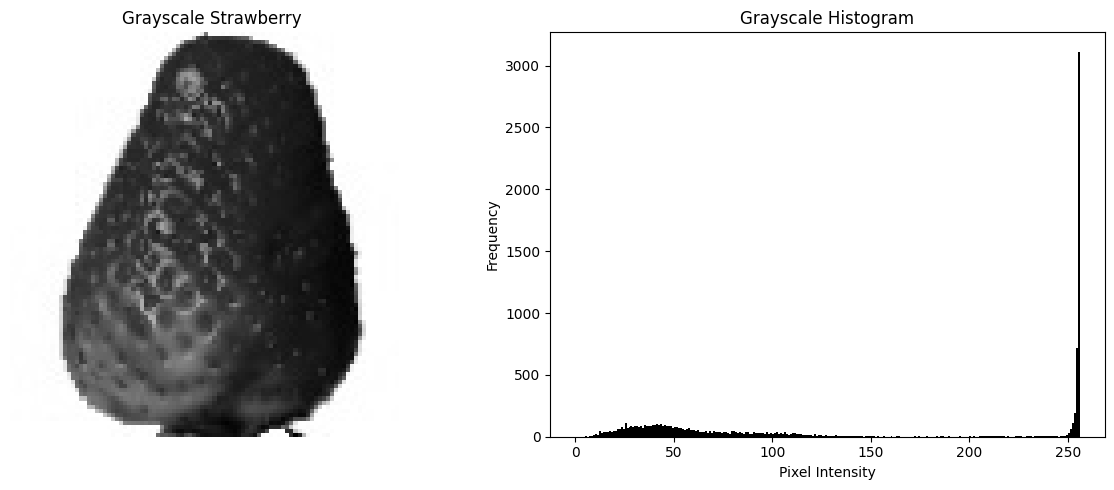

In [43]:
# 1. Load strawberry.jpg as grayscale
strawberry_path = image_paths['strawberry']
img_gray = cv2.imread(strawberry_path, cv2.IMREAD_GRAYSCALE)

# 2. Plot the histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Strawberry')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(img_gray.ravel(), 256, [0, 256], color='black')
plt.title('Grayscale Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

According to the histogram we can see that due to the rpesence of the White background there is a huge spike at aorund 255, else the image seems to the properly exposed


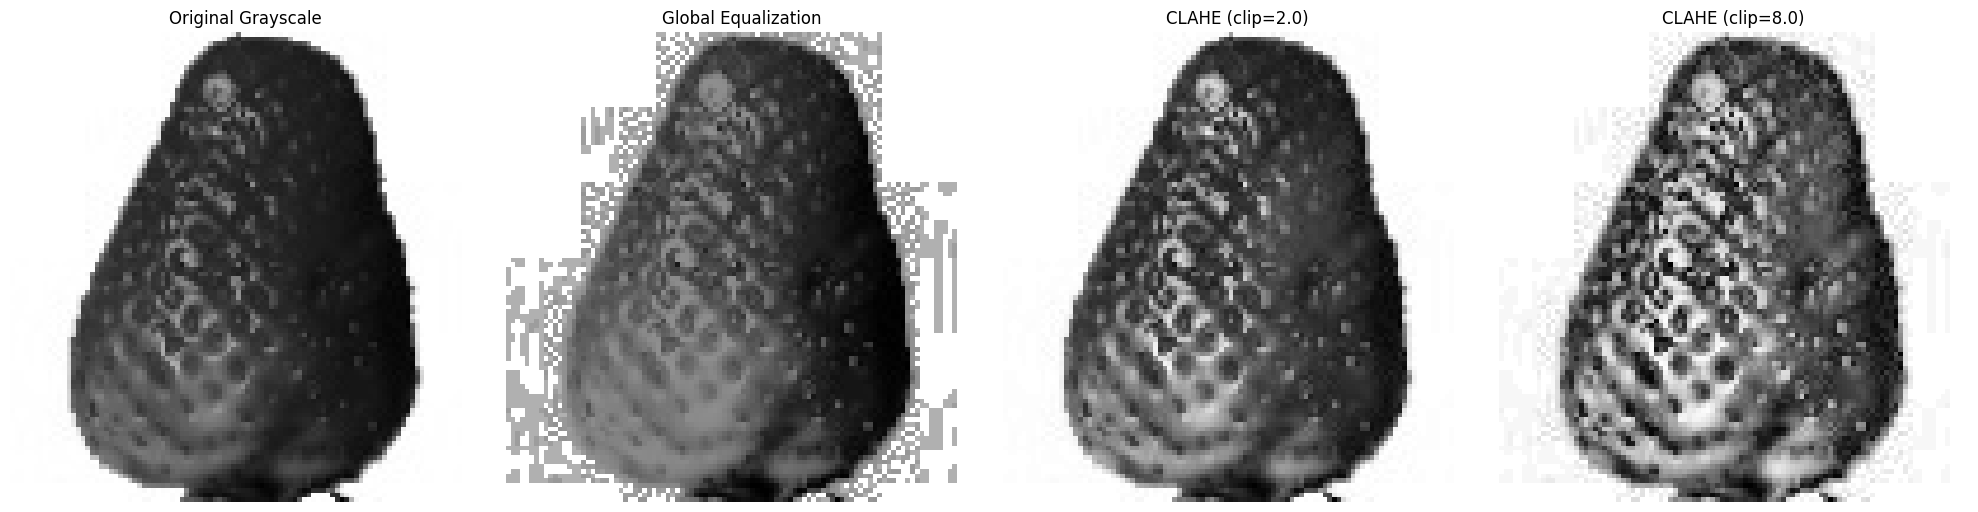

Observation: CLAHE with clipLimit=2.0 usually provides the best balance of contrast enhancement without washing out features or introducing noise.


In [44]:
# 2. Histogram Equalization and CLAHE
# Global Equalization
img_equalized = cv2.equalizeHist(img_gray)

# CLAHE with clipLimit=2.0
clahe2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe2 = clahe2.apply(img_gray)

# CLAHE with clipLimit=8.0
clahe8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8, 8))
img_clahe8 = clahe8.apply(img_gray)

# Visualization
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_equalized, cmap='gray')
plt.title('Global Equalization')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_clahe2, cmap='gray')
plt.title('CLAHE (clip=2.0)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_clahe8, cmap='gray')
plt.title('CLAHE (clip=8.0)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Observation: CLAHE with clipLimit=2.0 usually provides the best balance of contrast enhancement without washing out features or introducing noise.")

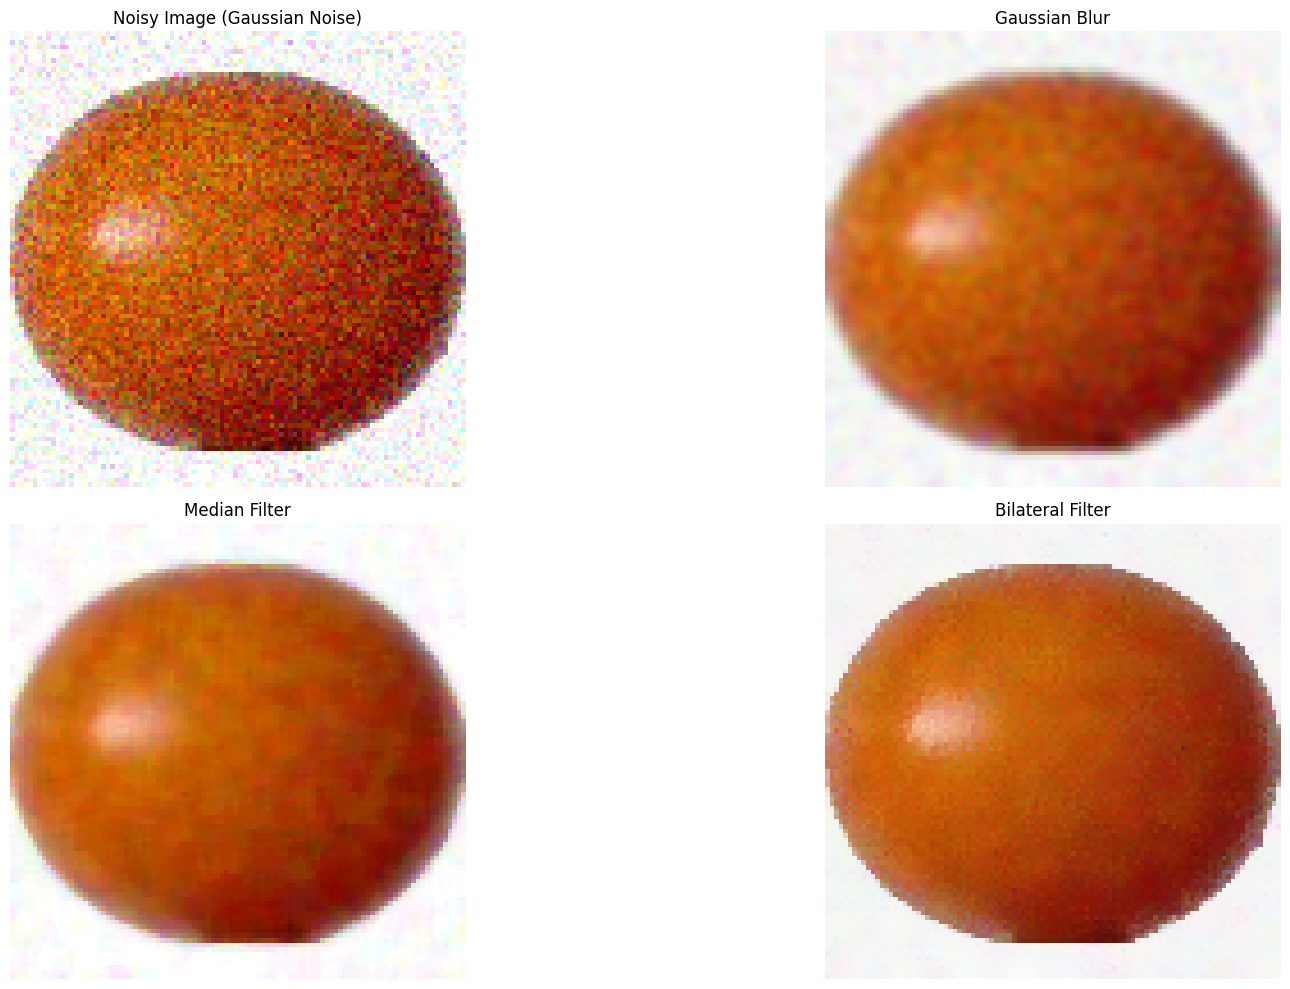

Observation: The Bilateral Filter typically removes the noise best while keeping the fruit's edge sharp.


In [45]:
# 1. Load orange.jpg
orange_bgr = cv2.imread(image_paths['orange'])
orange_rgb = cv2.cvtColor(orange_bgr, cv2.COLOR_BGR2RGB)

# 2. Add Gaussian noise (mean=0, std=25)
row, col, ch = orange_rgb.shape
mean = 0
std = 25
gauss = np.random.normal(mean, std, (row, col, ch)).astype('float32')
noisy_img = np.clip(orange_rgb.astype('float32') + gauss, 0, 255).astype('uint8')

# 3. Apply Filters
# Gaussian Blur
gaussian_blur = cv2.GaussianBlur(noisy_img, (5, 5), 0)

# Median Filter
median_filter = cv2.medianBlur(noisy_img, 5)

# Bilateral Filter (d=9, sigmaColor=75, sigmaSpace=75)
bilateral_filter = cv2.bilateralFilter(noisy_img, 9, 75, 75)

# 4. Plot Comparison
plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
plt.imshow(noisy_img)
plt.title('Noisy Image (Gaussian Noise)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gaussian_blur)
plt.title('Gaussian Blur')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(median_filter)
plt.title('Median Filter')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(bilateral_filter)
plt.title('Bilateral Filter')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Observation: The Bilateral Filter typically removes the noise best while keeping the fruit's edge sharp.")

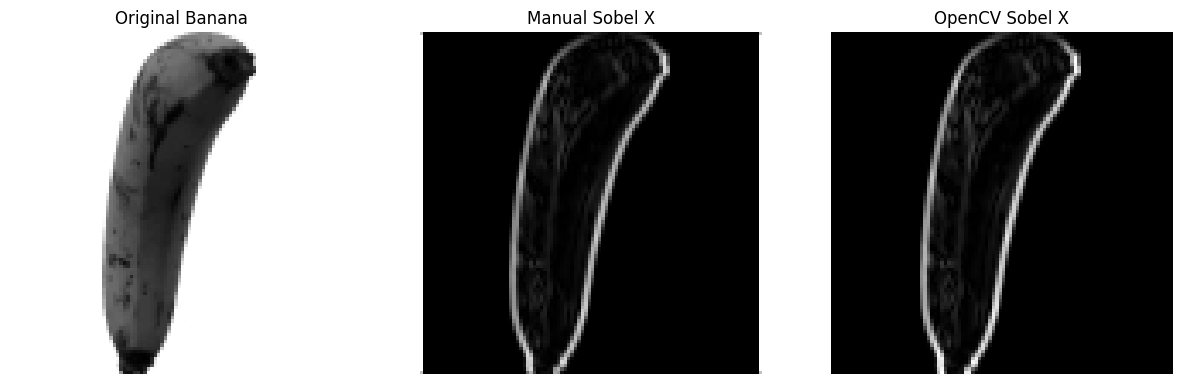

Mean Absolute Difference: 95.179001

Explanation: A difference of 0 indicates identical results. Small discrepancies can occur if OpenCV uses optimized floating-point instructions or different border handling (though we used constant padding to match).


In [46]:
def conv2d(image, kernel):
    # Get dimensions
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    # Calculate padding (same padding)
    pad_h, pad_w = ker_h // 2, ker_w // 2
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    # Flip kernel for convolution (mathematical definition)
    kernel = np.flipud(np.fliplr(kernel))

    output = np.zeros_like(image, dtype=np.float32)

    for i in range(img_h):
        for j in range(img_w):
            # Extract region of interest
            region = padded_img[i:i+ker_h, j:j+ker_w]
            output[i, j] = np.sum(region * kernel)

    return output

# 1. Load banana as grayscale
banana_gray = cv2.imread(image_paths['banana'], cv2.IMREAD_GRAYSCALE)

# 2. Define Sobel X kernel
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

# 3. Apply manual convolution
manual_conv = conv2d(banana_gray, sobel_x)

# 4. Apply cv2.filter2D
# Note: filter2D performs correlation by default, but Sobel X is symmetric/anti-symmetric
# so we check the difference directly.
cv2_conv = cv2.filter2D(banana_gray.astype(np.float32), -1, sobel_x)

# 5. Calculate MAD
mad = np.mean(np.abs(manual_conv - cv2_conv))

# Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(banana_gray, cmap='gray'); plt.title('Original Banana'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(np.abs(manual_conv), cmap='gray'); plt.title('Manual Sobel X'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(np.abs(cv2_conv), cmap='gray'); plt.title('OpenCV Sobel X'); plt.axis('off')
plt.show()

print(f"Mean Absolute Difference: {mad:.6f}")
print("\nExplanation: A difference of 0 indicates identical results. Small discrepancies can occur if OpenCV uses optimized floating-point instructions or different border handling (though we used constant padding to match).")

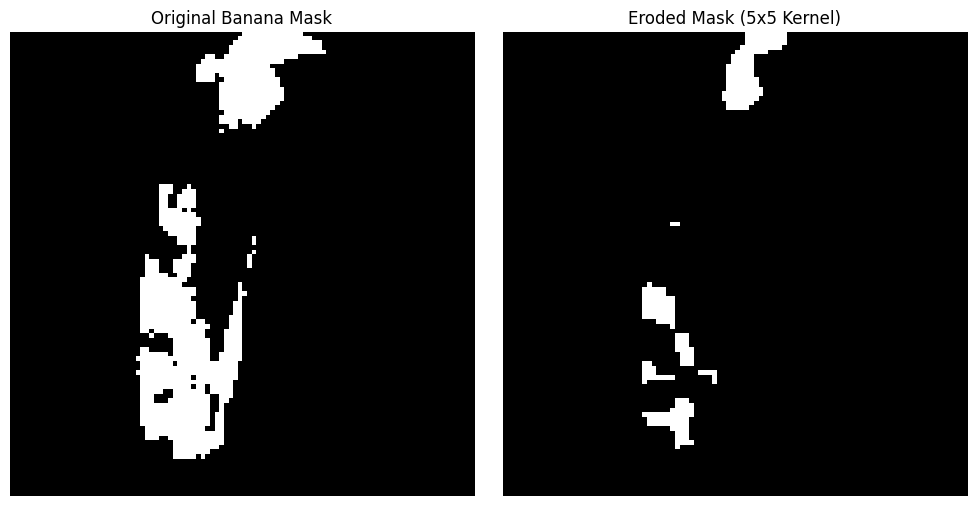

Observation: Erosion removes small white noise (foreground) but also shrinks the actual fruit boundary and expands internal holes.


In [47]:
# 5. Erosion on Banana Mask
# Re-generate the banana mask from Part A
banana_bgr = cv2.imread(image_paths['banana'])
low_banana, high_banana = np.array(ranges['banana'][0]), np.array(ranges['banana'][1])
banana_mask, _ = get_mask(banana_bgr, low_banana, high_banana)

# Define a 5x5 kernel
kernel = np.ones((5, 5), np.uint8)

# Apply erosion
eroded_mask = cv2.erode(banana_mask, kernel, iterations=1)

# Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(banana_mask, cmap='gray')
plt.title('Original Banana Mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(eroded_mask, cmap='gray')
plt.title('Eroded Mask (5x5 Kernel)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Observation: Erosion removes small white noise (foreground) but also shrinks the actual fruit boundary and expands internal holes.")

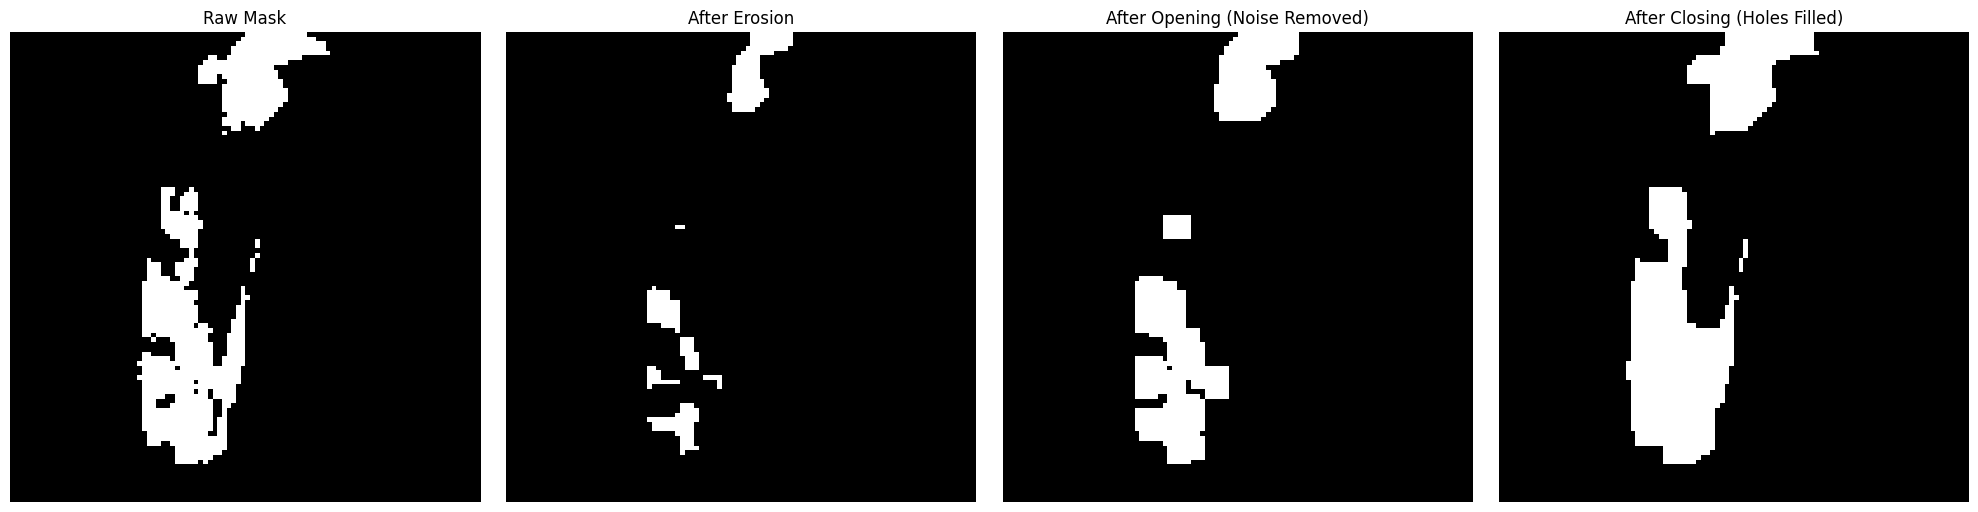

In [48]:
# 6. Opening and Closing for Noise Removal and Hole Filling
# Define kernel
kernel = np.ones((5, 5), np.uint8)

# Opening: Erosion followed by Dilation (removes small white noise)
opened_mask = cv2.morphologyEx(banana_mask, cv2.MORPH_OPEN, kernel)

# Closing: Dilation followed by Erosion (fills small black holes)
closed_mask = cv2.morphologyEx(banana_mask, cv2.MORPH_CLOSE, kernel)

# Visualization
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(banana_mask, cmap='gray')
plt.title('Raw Mask')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(eroded_mask, cmap='gray')
plt.title('After Erosion')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(opened_mask, cmap='gray')
plt.title('After Opening (Noise Removed)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(closed_mask, cmap='gray')
plt.title('After Closing (Holes Filled)')
plt.axis('off')

plt.tight_layout()
plt.show()

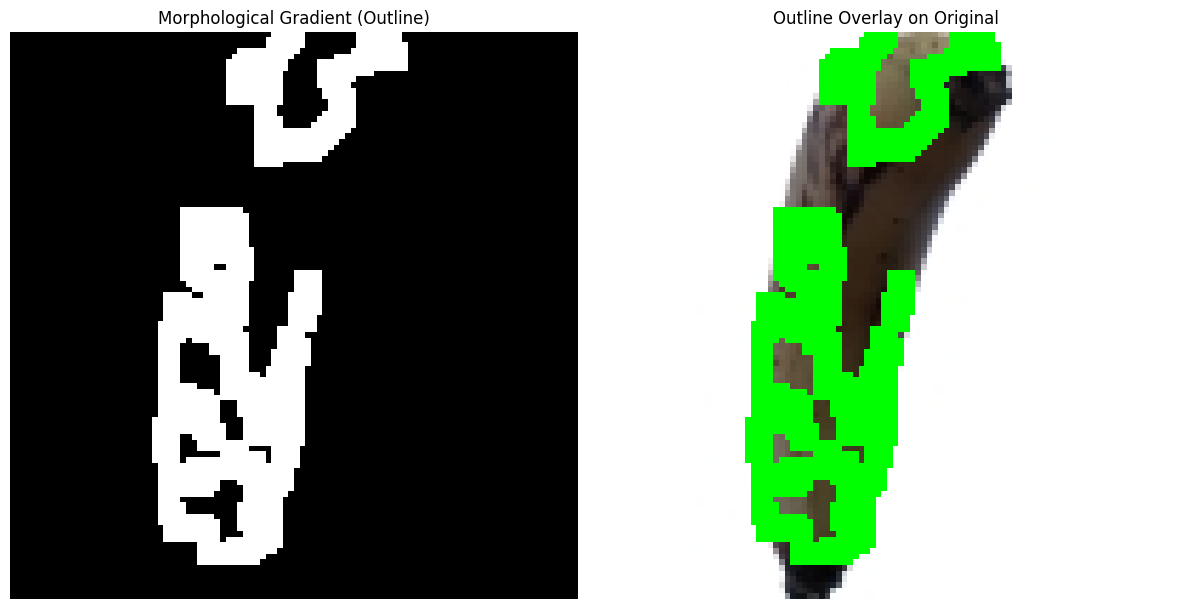

In [49]:
# 7. Morphological Gradient and Overlay
# Calculate morphological gradient (dilation - erosion)
gradient = cv2.morphologyEx(banana_mask, cv2.MORPH_GRADIENT, kernel)

# Create an overlay by copying the original BGR image
overlay = banana_bgr.copy()

# Set the pixels where the gradient is present to Green [0, 255, 0] in BGR
overlay[gradient > 0] = [0, 255, 0]

# Visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(gradient, cmap='gray')
plt.title('Morphological Gradient (Outline)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title('Outline Overlay on Original')
plt.axis('off')

plt.tight_layout()
plt.show()

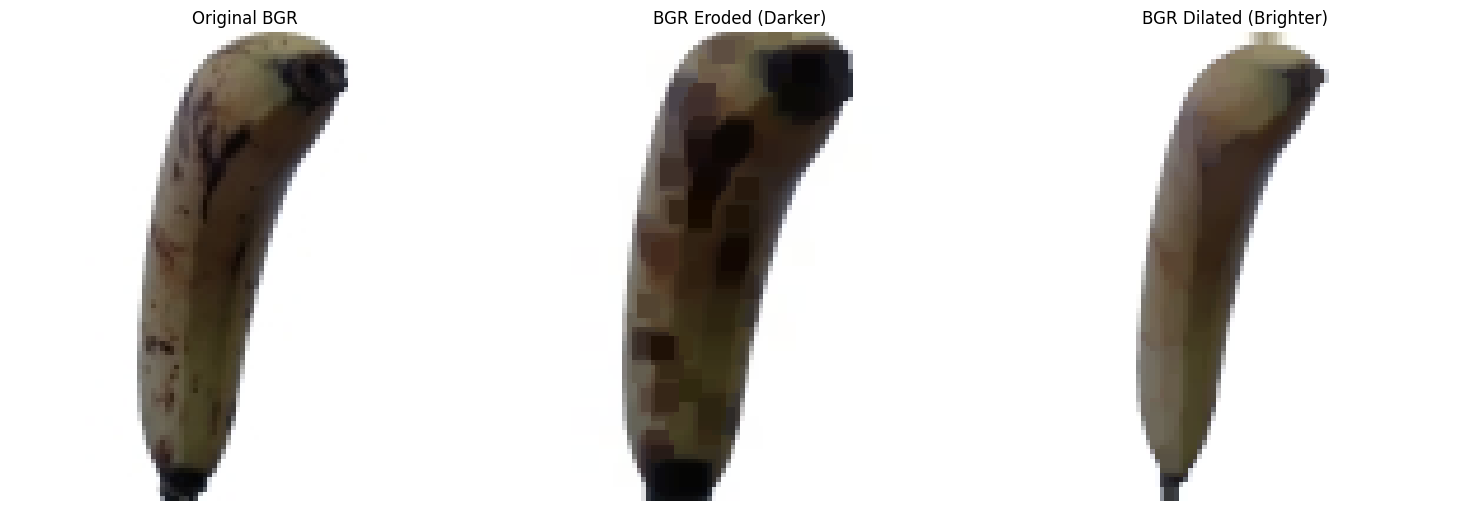

Reflection: When applied to BGR images, morphological operations act on the intensity values of each channel.
Erosion: Picks the minimum intensity in the neighborhood, making dark features (like bruises or shadows) thicker and the image darker.
Dilation: Picks the maximum intensity, making highlights/white background expand and the fruit appear thinner and brighter.


In [50]:
# 8. Reflection: Morphological Operations on BGR image
kernel_bgr = np.ones((5, 5), np.uint8)

# Apply erosion and dilation directly to the BGR image
bgr_eroded = cv2.erode(banana_bgr, kernel_bgr)
bgr_dilated = cv2.dilate(banana_bgr, kernel_bgr)

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2RGB))
plt.title('Original BGR')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(bgr_eroded, cv2.COLOR_BGR2RGB))
plt.title('BGR Eroded (Darker)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(bgr_dilated, cv2.COLOR_BGR2RGB))
plt.title('BGR Dilated (Brighter)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Reflection: When applied to BGR images, morphological operations act on the intensity values of each channel.")
print("Erosion: Picks the minimum intensity in the neighborhood, making dark features (like bruises or shadows) thicker and the image darker.")
print("Dilation: Picks the maximum intensity, making highlights/white background expand and the fruit appear thinner and brighter.")

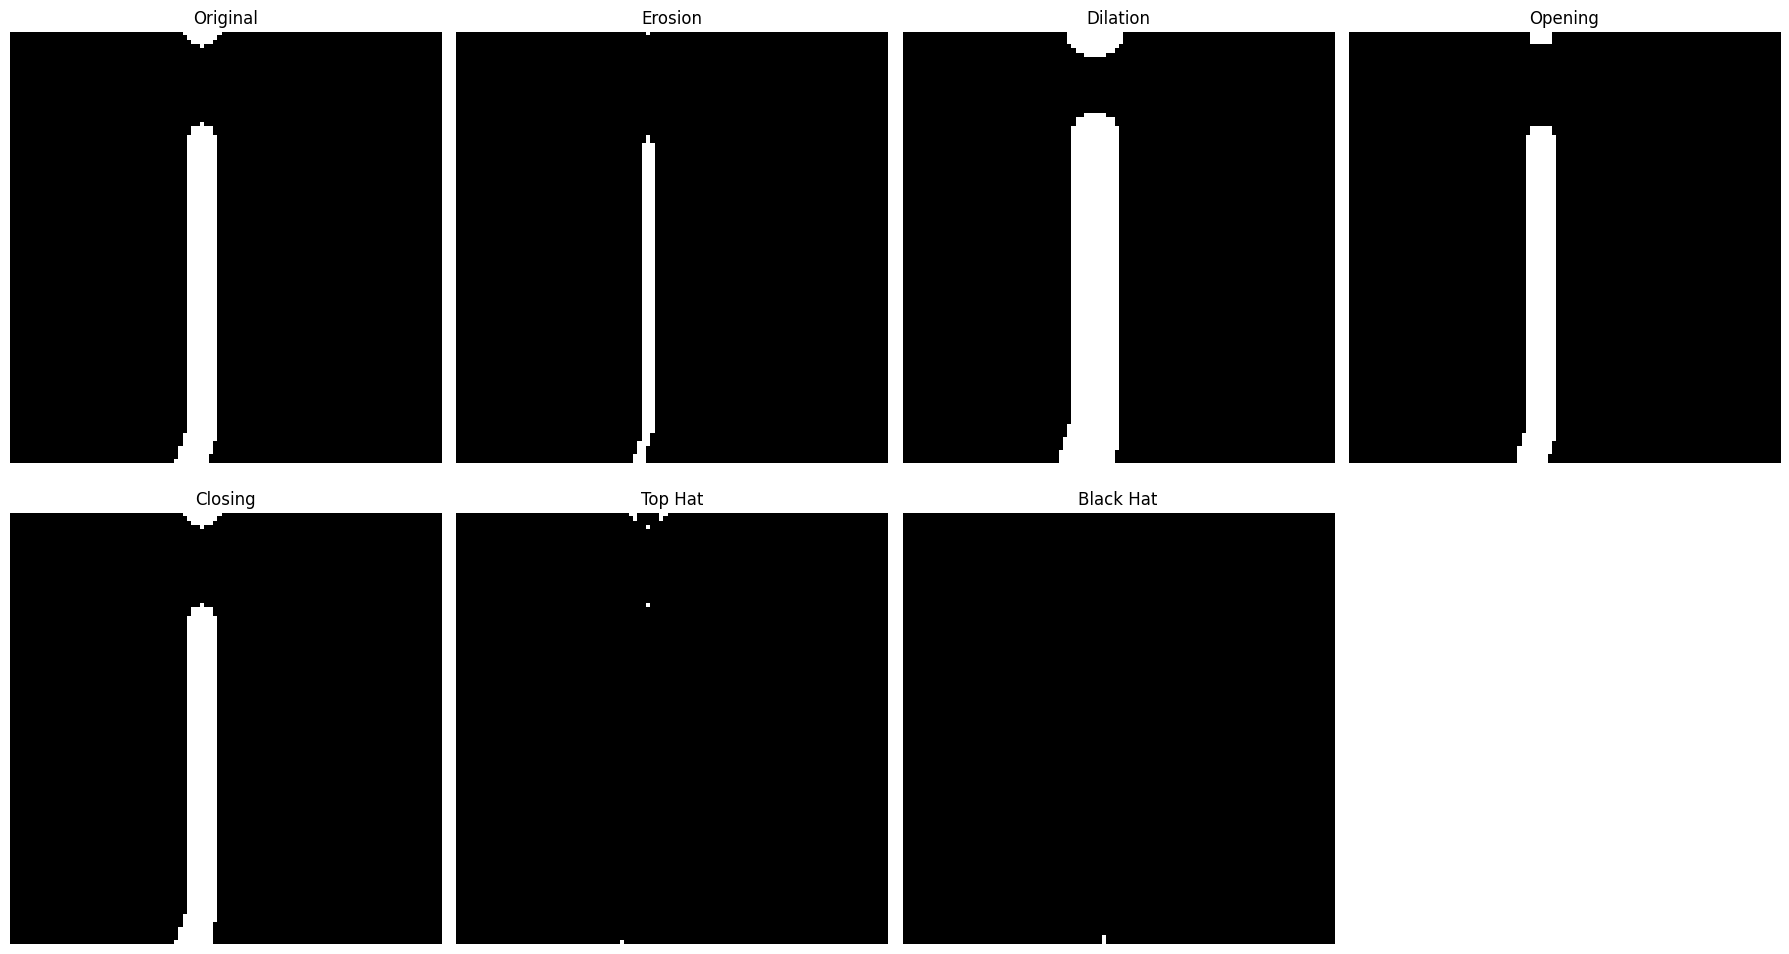

Question: Which operation isolates the thin strokes?
Answer: The Top Hat operation isolates the thin strokes (the difference between the original image and its opening).


In [51]:
# 9. Demo with morphological operations
# Creating a synthetic 'j' image since j.png isn't in the workspace
j_img = np.zeros((100, 100), dtype=np.uint8)
# Drawing a simple 'j' shape
cv2.putText(j_img, 'j', (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 4, 255, 5)

kernel = np.ones((5, 5), np.uint8)

# Morphological operations
erosion = cv2.erode(j_img, kernel, iterations=1)
dilation = cv2.dilate(j_img, kernel, iterations=1)
opening = cv2.morphologyEx(j_img, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(j_img, cv2.MORPH_CLOSE, kernel)
tophat = cv2.morphologyEx(j_img, cv2.MORPH_TOPHAT, kernel)
blackhat = cv2.morphologyEx(j_img, cv2.MORPH_BLACKHAT, kernel)

# Visualization
results = [
    (j_img, 'Original'), (erosion, 'Erosion'),
    (dilation, 'Dilation'), (opening, 'Opening'),
    (closing, 'Closing'), (tophat, 'Top Hat'), (blackhat, 'Black Hat')
]

plt.figure(figsize=(18, 10))
for i, (img, title) in enumerate(results):
    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Question: Which operation isolates the thin strokes?")
print("Answer: The Top Hat operation isolates the thin strokes (the difference between the original image and its opening).")

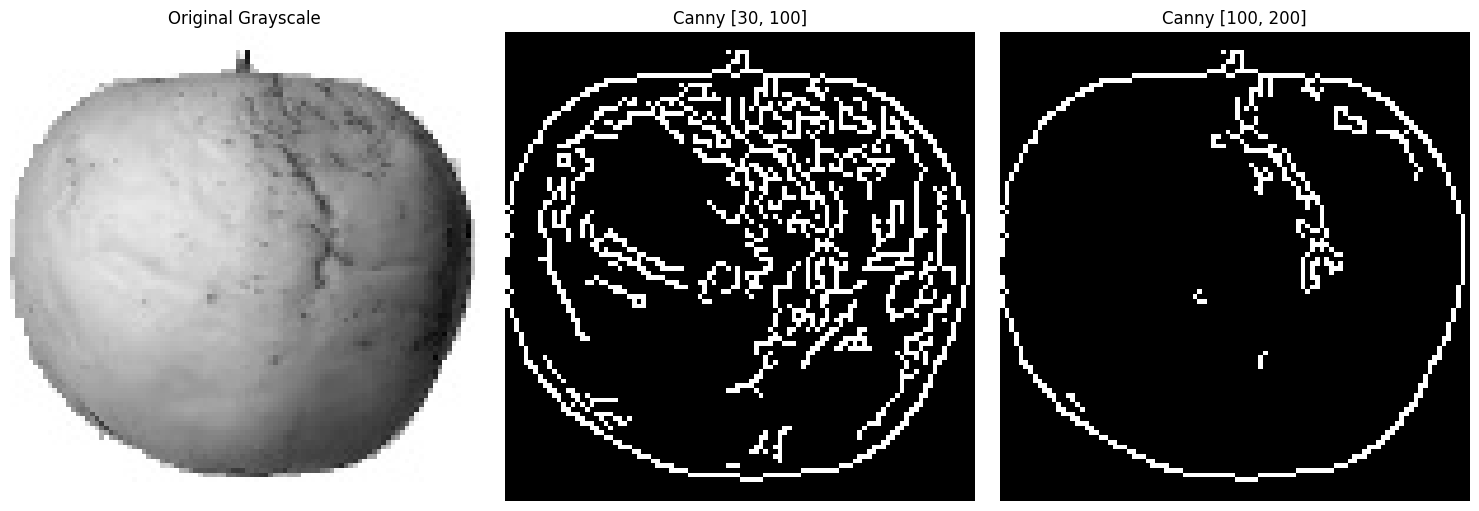

Analysis: The [100, 200] pair usually captures the outline more cleanly. The [30, 100] pair is more sensitive and often picks up internal texture or noise as edges.

Canny Pipeline Stages:
1. Noise Reduction: Apply a Gaussian filter to smooth the image.
2. Gradient Calculation: Find intensity gradients using Sobel kernels.
3. Non-Maximum Suppression: Thin out edges by keeping only local maxima in the gradient direction.
4. Double Thresholding: Identify potential edges as strong, weak, or non-edges based on the thresholds.
5. Hysteresis: Finalize edges by keeping weak edges only if they are connected to strong edges.


In [52]:
# 10. Canny Edge Detection
# Load green_apple as grayscale
green_apple_gray = cv2.imread(image_paths['green_apple'], cv2.IMREAD_GRAYSCALE)

# Apply Canny with different thresholds
edges_low = cv2.Canny(green_apple_gray, 30, 100)
edges_high = cv2.Canny(green_apple_gray, 100, 200)

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(green_apple_gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_low, cmap='gray')
plt.title('Canny [30, 100]')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges_high, cmap='gray')
plt.title('Canny [100, 200]')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Analysis: The [100, 200] pair usually captures the outline more cleanly. The [30, 100] pair is more sensitive and often picks up internal texture or noise as edges.")

print("\nCanny Pipeline Stages:")
print("1. Noise Reduction: Apply a Gaussian filter to smooth the image.")
print("2. Gradient Calculation: Find intensity gradients using Sobel kernels.")
print("3. Non-Maximum Suppression: Thin out edges by keeping only local maxima in the gradient direction.")
print("4. Double Thresholding: Identify potential edges as strong, weak, or non-edges based on the thresholds.")
print("5. Hysteresis: Finalize edges by keeping weak edges only if they are connected to strong edges.")

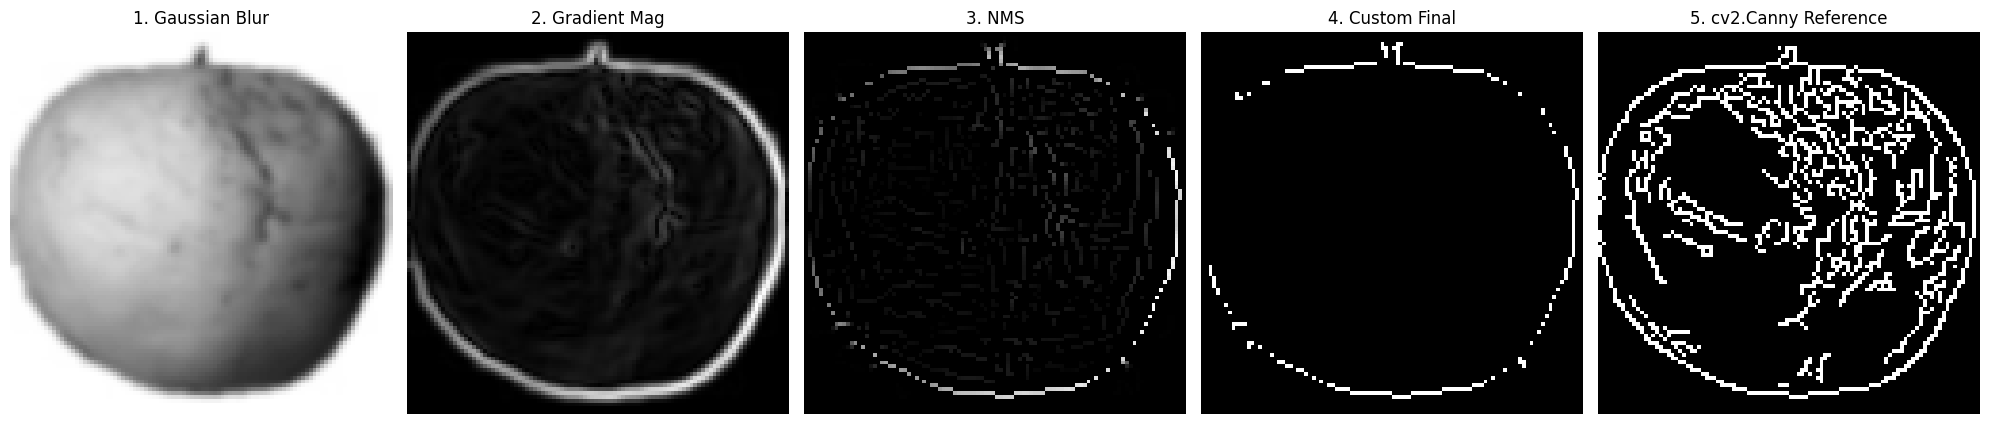

In [53]:
class CannyEdgeDetector:
    def __init__(self, low_threshold=50, high_threshold=150, kernel_size=5, sigma=1):
        self.low_threshold = low_threshold
        self.high_threshold = high_threshold
        self.kernel_size = kernel_size
        self.sigma = sigma

    def apply_pipeline(self, img):
        # 1. Noise Reduction (Gaussian Blur)
        self.blurred = cv2.GaussianBlur(img, (self.kernel_size, self.kernel_size), self.sigma)

        # 2. Gradient Calculation (Sobel)
        gx = cv2.Sobel(self.blurred, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(self.blurred, cv2.CV_64F, 0, 1, ksize=3)
        self.magnitude = np.sqrt(gx**2 + gy**2)
        self.theta = np.arctan2(gy, gx)

        # 3. Non-Maximum Suppression
        self.nms = self._non_max_suppression(self.magnitude, self.theta)

        # 4. Double Thresholding
        self.thresholded, weak, strong = self._double_threshold(self.nms)

        # 5. Hysteresis
        self.final_edges = self._hysteresis(self.thresholded, weak, strong)

        return self.final_edges

    def _non_max_suppression(self, mag, theta):
        rows, cols = mag.shape
        z = np.zeros((rows, cols), dtype=np.float32)
        angle = theta * 180. / np.pi
        angle[angle < 0] += 180

        for i in range(1, rows-1):
            for j in range(1, cols-1):
                q, r = 255, 255
                # Angle 0 (horizontal)
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q, r = mag[i, j+1], mag[i, j-1]
                # Angle 45
                elif (22.5 <= angle[i,j] < 67.5):
                    q, r = mag[i+1, j-1], mag[i-1, j+1]
                # Angle 90 (vertical)
                elif (67.5 <= angle[i,j] < 112.5):
                    q, r = mag[i+1, j], mag[i-1, j]
                # Angle 135
                elif (112.5 <= angle[i,j] < 157.5):
                    q, r = mag[i-1, j-1], mag[i+1, j+1]

                if (mag[i,j] >= q) and (mag[i,j] >= r):
                    z[i,j] = mag[i,j]
                else:
                    z[i,j] = 0
        return z

    def _double_threshold(self, img):
        high = img.max() * (self.high_threshold / 255)
        low = high * (self.low_threshold / self.high_threshold)
        res = np.zeros_like(img)

        weak, strong = 50, 255
        res[img >= high] = strong
        res[(img <= high) & (img >= low)] = weak
        return res, weak, strong

    def _hysteresis(self, img, weak, strong=255):
        rows, cols = img.shape
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if (img[i,j] == weak):
                    if ((img[i+1, j-1:j+2] == strong).any() or
                        (img[i-1, j-1:j+2] == strong).any() or
                        (img[i, j-1] == strong) or (img[i, j+1] == strong)):
                        img[i,j] = strong
                    else:
                        img[i,j] = 0
        return img

# Run Custom Canny
detector = CannyEdgeDetector(low_threshold=30, high_threshold=100)
custom_edges = detector.apply_pipeline(green_apple_gray)

# Visualization of stages
plt.figure(figsize=(20, 10))
stages = [(detector.blurred, '1. Gaussian Blur'), (detector.magnitude, '2. Gradient Mag'),
          (detector.nms, '3. NMS'), (custom_edges, '4. Custom Final'), (edges_low, '5. cv2.Canny Reference')]

for i, (img, title) in enumerate(stages):
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

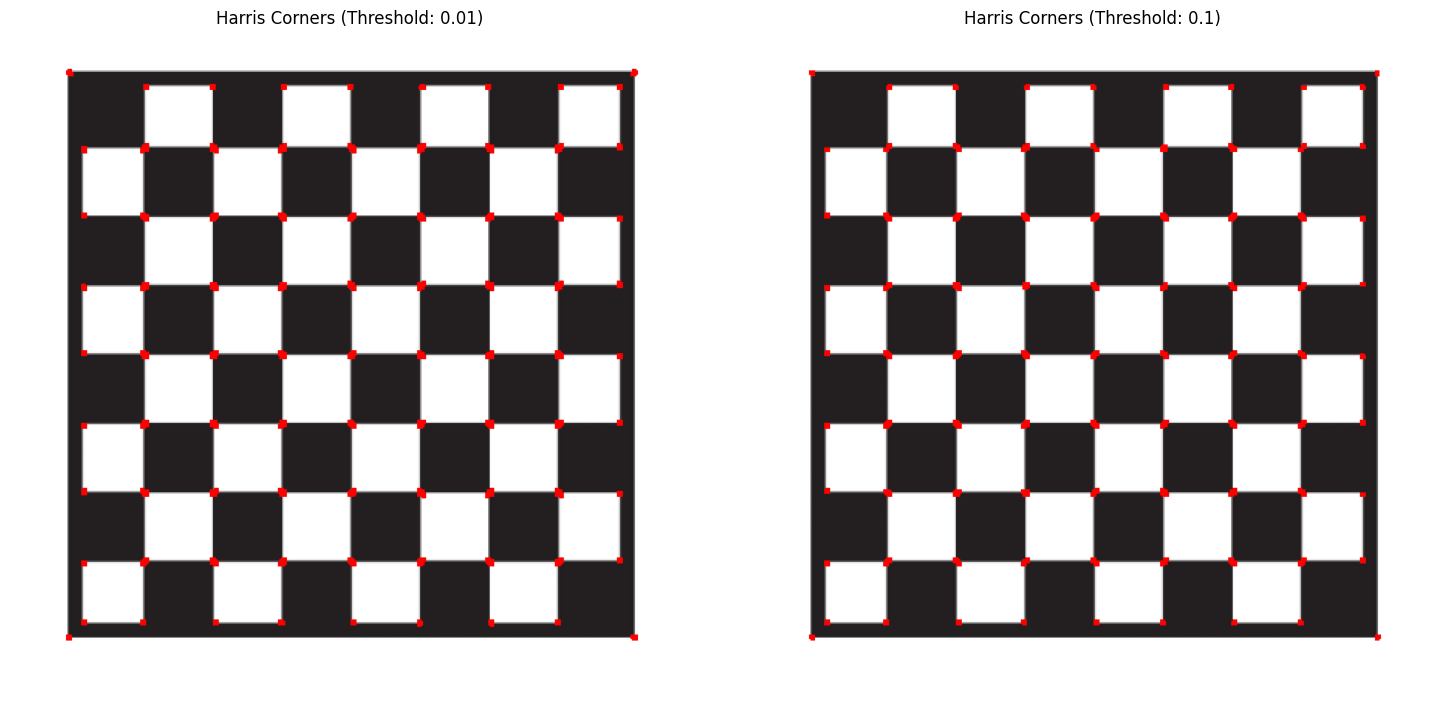

Observation: Increasing the threshold from 0.01 to 0.1 significantly reduces the number of detected points.
At 0.01, you might see false positives or clusters of points around a single corner. At 0.1, only the strongest local maxima remain marked.


In [54]:
# 12. Harris Corner Detection on chessboard.jpg
# Load the chessboard image
cb_bgr = cv2.imread(image_paths['chessboard'])
cb_gray = cv2.cvtColor(cb_bgr, cv2.COLOR_BGR2GRAY)

# Harris Corner parameters
# blockSize: neighborhood size for corner detection
# ksize: aperture parameter for Sobel operator
# k: Harris detector free parameter
dst = cv2.cornerHarris(cb_gray.astype(np.float32), blockSize=2, ksize=3, k=0.04)

# Dilate the response map to make the corner points visible
dst = cv2.dilate(dst, None)

# Define thresholds
threshold_low = 0.01 * dst.max()
threshold_high = 0.1 * dst.max()

# Create result copies
img_low = cb_bgr.copy()
img_high = cb_bgr.copy()

# Mark corners as red dots [0, 0, 255] in BGR
img_low[dst > threshold_low] = [0, 0, 255]
img_high[dst > threshold_high] = [0, 0, 255]

# Visualization
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_low, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners (Threshold: 0.01)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_high, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners (Threshold: 0.1)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Observation: Increasing the threshold from 0.01 to 0.1 significantly reduces the number of detected points.")
print("At 0.01, you might see false positives or clusters of points around a single corner. At 0.1, only the strongest local maxima remain marked.")

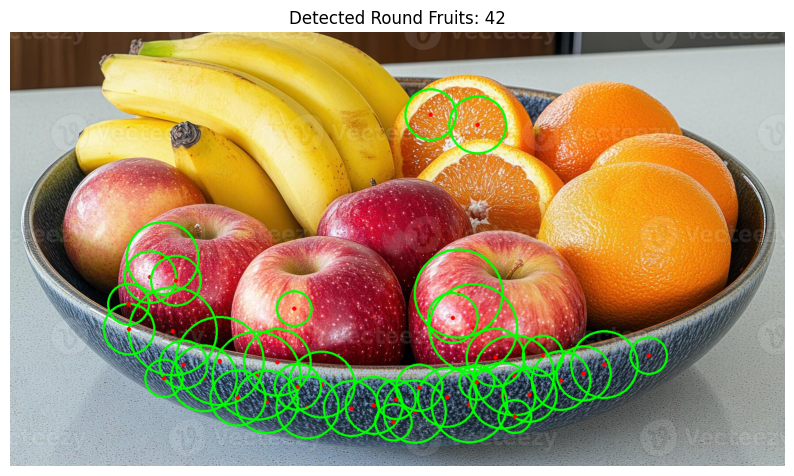

Detector counted 42 round fruits.
Note: The count depends heavily on param2. If it misses fruits, decrease param2; if it finds false circles, increase it.


In [64]:
# 13. Hough Circle Transform on mixed_bowl.jpg
# Load the mixed fruit bowl image
mixed_bgr = cv2.imread(image_paths['mixed_bowl'])
mixed_gray = cv2.cvtColor(mixed_bgr, cv2.COLOR_BGR2GRAY)

# Pre-processing: Blur is essential for reducing noise before Hough Circles
mixed_blurred = cv2.medianBlur(mixed_gray, 5)

# Apply Hough Circle Transform
# param1: Higher threshold for Canny edge detector passed to Hough
# param2: Accumulator threshold - lower values = more (potentially false) circles
circles = cv2.HoughCircles(
    mixed_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=100,
    param2=60,
    minRadius=30,
    maxRadius=100
)

# Create a copy for drawing
output_img = mixed_bgr.copy()
count = 0

if circles is not None:
    circles = np.uint16(np.around(circles))
    count = circles.shape[1]
    for i in circles[0, :]:
        # Draw the outer circle (green)
        cv2.circle(output_img, (i[0], i[1]), i[2], (0, 255, 0), 3)
        # Draw the center of the circle (red)
        cv2.circle(output_img, (i[0], i[1]), 2, (0, 0, 255), 5)

# Visualization
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Round Fruits: {count}')
plt.axis('off')
plt.show()

print(f"Detector counted {count} round fruits.")
print("Note: The count depends heavily on param2. If it misses fruits, decrease param2; if it finds false circles, increase it.")